In [2]:
import xarray as xr
import netCDF4
import numpy as np
import numpy.ma as ma
from datetime import datetime as dt
from datetime import timedelta

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import glob, sys, os, re
from pprint import pprint
import subprocess

In [3]:
sim_dir = "/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km"
fig_dir = '../figures'

In [4]:
# Define simulation subfolders
sim_names = [f for f in os.listdir(sim_dir) if re.match("(.*)2016(.*)",f) ]
sim_names.sort(reverse=True)
print(sim_names)

['t0_20160910_00', 'p6_20160910_06', 'p12_20160910_12']


In [176]:
for simname in sim_names:

    print(os.path.join(sim_dir,simname,"*"))
    # pprint(glob.glob(os.path.join(sim_dir,simname,'*')))
    # pprint(os.listdir(os.path.join(sim_dir,simname,'seg0?_*h')))
    file_list = glob.glob(os.path.join(sim_dir,simname,'seg0?_*h_tege','*.OUT.*.nc'))
    file_list.sort()
    pprint(len(file_list))
    print()

/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/t0_20160910_00/*
72

/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/p6_20160910_06/*
72

/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/p12_20160910_12/*
72



In [174]:
# Load all sims at a specific time

def getMNHFileAtTime(target_time,time_ref=dt(2016,9,10),lag_h=0):
    """For a given lag (in hours) at the start of the simulation,
    get the filename of the right simulation at that given time.
    """

    # simulation index
    i_lag = np.where(lags_h == lag_h)[0][0]
    # simulation output hourly frequency
    Dt = time_freq_MNH/3600
    
    #-- get corresponding time file
    # time difference
    delta_t = target_time - (time_ref+timedelta(seconds=lag_h*3600))
    # find corresponding subfolder
    i_seg = int((delta_t.total_seconds()/3600/Dt - 1) / (12/Dt) ) +1 # segment number
    subfolder = "seg0%d_12h_tege"%i_seg
    # build corresponding filename
    i_t_seg = int((delta_t.total_seconds()/3600/Dt - 1) % int(12/Dt) + 1)
    filename = "FBC01.1.MNH0%d.OUT.%s.nc"%(i_seg,str(i_t_seg).zfill(3))
    # full path
    path = os.path.join(sim_dir,sim_names[i_lag],subfolder,filename)

    return path


In [162]:
##-- Define lags between simulations

lags_h = np.array([0,6,12])

lag_6h = timedelta(seconds=6*3600)
lag_12h = timedelta(seconds=12*3600)
time_ref = dt(2016,9,10)

# target_time = dt(2016,9,10,13,00)
# target_time = dt(2016,9,10,14,00)
target_time = dt(2016,9,10,20,30)

def getAdjustedTime(target_time,time_freq=1800):
    """Adjust the target datetime to the current time, according to the frequency of data files.

    Args:
    - target_time (datetime object): target time
    - time_freq (float): frequency of the data files, in s

    Returns:
    - adjusted time (datetime object): adjusted time on the data files time array.
    """

    # compute the number of seconds of IMERG file since start of day
    n_steps = int((target_time-dt(target_time.year,target_time.month,target_time.day)).seconds / (time_freq))
    adjusted_seconds = int(n_steps * time_freq)
    # adjusted time
    adjusted_time = dt(target_time.year,target_time.month,target_time.day)+timedelta(seconds=adjusted_seconds)

    return adjusted_time

time_freq_IMERG = 1800 # s
time_freq_MNH = 1200 # s

# Adjusted time for IMERG file
target_time_IMERG = getAdjustedTime(target_time,time_freq_IMERG)
# Adjusted time for MNH files
target_time_MNH = getAdjustedTime(target_time,time_freq_MNH)

##-- Define bounds in Prec
vmin = 1 # mm/h
# vmax = 40 # mm/h

In [175]:
##-- Get Meso-NH data and coords

#- Datasets

data_lag0 = xr.open_dataset(getMNHFileAtTime(target_time_MNH,lag_h=0))
data_lag6 = xr.open_dataset(getMNHFileAtTime(target_time_MNH,lag_h=6))
data_lag12 = xr.open_dataset(getMNHFileAtTime(target_time_MNH,lag_h=12))

#- Domain coords
lon_array = data_lag0.longitude.values
lat_array = data_lag0.latitude.values
longitude = data_lag0.longitude[0].values
latitude = data_lag0.latitude[:,0].values
extent = [longitude[0],longitude[-1],latitude[0],latitude[-1]]

In [ ]:
data_lag0

In [94]:
#- Cap Prec data in target range

# Conversion factors
time_step = 3 # s
s_to_h = 1/3600
rho_w = 1e3 # km/m3
m_to_mm = 1e3 

prec_lag0 = data_lag0.ACPRRSTEP[0].values / (time_step * s_to_h) / rho_w * m_to_mm # mm/h
prec_lag0[prec_lag0 < vmin] = np.nan
prec_lag6 = data_lag6.ACPRRSTEP[0].values / (time_step * s_to_h) / rho_w * m_to_mm # mm/h
prec_lag6[prec_lag6 < vmin] = np.nan
prec_lag12 = data_lag12.ACPRRSTEP[0].values / (time_step * s_to_h) / rho_w * m_to_mm # mm/h
prec_lag12[prec_lag12 < vmin] = np.nan



In [42]:
##-- Path to observed IMERG Precipitation
#
# Data copied to jeanzay from spirit1:/bdd/GPM/IMERG/V07/final/
#

# define observations data path
parent_dir = '/lustre/fswork/projects/rech/lsv/uae56hc/observations/GPM/IMERG/V07/final/'
data_dir = os.path.join(parent_dir,str(target_time.year),str(target_time.month).rjust(2, '0'),str(target_time.day).rjust(2, '0'))
# create file name
date_str = target_time_IMERG.strftime("%Y%m%d")
time_slot_start = target_time_IMERG.strftime("%H%M%S")
time_slot_end = (target_time_IMERG+timedelta(seconds=1800-1)).strftime("%H%M%S")
mn_since_midnight = "%04.0f"%((target_time_IMERG-dt(year=target_time_IMERG.year,month=target_time_IMERG.month,day=target_time_IMERG.day)).seconds/60)
file_name = '3B-HHR.MS.MRG.3IMERG.%s-S%s-E%s.%s.V07B.HDF5'%(date_str,time_slot_start,time_slot_end,mn_since_midnight)
# create file path 
file_path = os.path.join(data_dir,file_name)

In [71]:
# import h5py

In [72]:
# ##-- Visualise Obs file contents

# def preview_hdf5(name,obj):
#     if isinstance(obj, h5py.Group):
#         print(f"Group: {name}")
#     elif isinstance(obj, h5py.Dataset):
#         print(f"Dataset: {name}")

# with h5py.File(file_path,'r') as f:
#     f.visititems(preview_hdf5)

In [73]:
# ##-- Read precipiation group
# with h5py.File(file_path,'r') as f:
#     prec_data = f['Grid/precipitation']
#     print("Grid precipitation:")
#     print(prec_data[...])

#     lon_data = f['Grid/lat']
#     print("longitudes")

In [77]:
##-- Open hdf5 IMERG data in xarray format

# First read hdf5 file with netCDF4 in diskless non-persistence mode
ncf = netCDF4.Dataset(file_path, diskless=True, persist=False)
# print(ncf)
# Read groups
nch = ncf.groups.get('Grid')
# Read data
data_obs = xr.open_dataset(xr.backends.NetCDF4DataStore(nch))

In [ ]:
data_obs

In [125]:
##-- Format observations to display

# Select the same region as in Meso-NH
lon_slice = slice(extent[0],extent[1])
lat_slice = slice(extent[2],extent[3])
longitude_obs = data_obs.lon.sel(lon=lon_slice)
latitude_obs = data_obs.lat.sel(lat=lat_slice)
lon_array_obs, lat_array_obs = np.meshgrid(longitude_obs,latitude_obs)

# Crop observed Prec to domain
prec_imerg = data_obs.precipitation[0].sel(lon=lon_slice,lat=lat_slice).values.T # transposing to reorder dimensions

# Cap data in range
prec_imerg[prec_imerg < vmin] = np.nan
# prec_imerg[prec_imerg > vmax] = np.nan

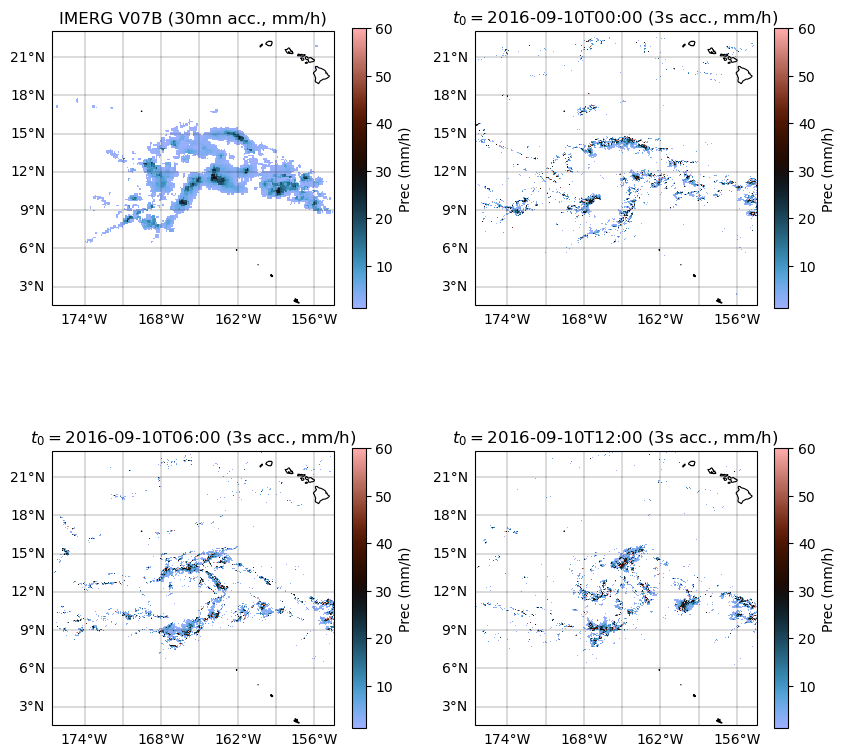

In [177]:
def showSubplot(lon_array, lat_array, data_var, data_crs, extent, vmin=1, vmax=60, cmap=plt.cm.berlin):
    
    ax.set_extent(extent, crs=data_crs)
    # data
    pcm = ax.pcolormesh(lon_array, lat_array, 
                        data_var,
                        transform=data_crs,
                        vmin = vmin,
                        vmax = vmax,
                        cmap=cmap)
    # Côtes
    ax.coastlines(resolution='10m', color='black', linewidth=0.8)
    # grille
    gl = ax.gridlines(crs=data_crs, draw_labels=True,
                       color='black', linewidth=0.2, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    # colorbar
    cb = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.8)
    cb.ax.set_ylabel('Prec (mm/h)')


data_crs = ccrs.PlateCarree()  # projection de vos données lon/lat

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10),
                         subplot_kw={'projection': data_crs})
axs = axs.flatten()

##-- (0) observations
ax = axs[0]
showSubplot(lon_array_obs, lat_array_obs, prec_imerg, data_crs, extent)
ax.set_title('IMERG V07B (30mn acc., mm/h)')

##-- (1) simulations depuis t=0
ax = axs[1]
showSubplot(lon_array, lat_array, prec_lag0, data_crs, extent)
ax.set_title('$t_0 = $%s (3s acc., mm/h)'%(dt.strftime(time_ref,"%Y-%m-%dT%H:%M")))

##-- (2) simulations depuis t=6h
ax = axs[2]
showSubplot(lon_array, lat_array, prec_lag6, data_crs, extent)
ax.set_title('$t_0 = $%s (3s acc., mm/h)'%(dt.strftime(time_ref+lag_6h,"%Y-%m-%dT%H:%M")))

##-- (3) simulations depuis t=12h
ax = axs[3]
showSubplot(lon_array, lat_array, prec_lag12, data_crs, extent)
ax.set_title('$t_0 = $%s (3s acc., mm/h)'%(dt.strftime(time_ref+lag_12h,"%Y-%m-%dT%H:%M")))

save_path = os.path.join(fig_dir,'RC5_comparison_t0_%s.png'%(dt.strftime(target_time,"%Y%m%dT%H%M")))
plt.savefig(save_path,bbox_inches='tight')